Original Image:


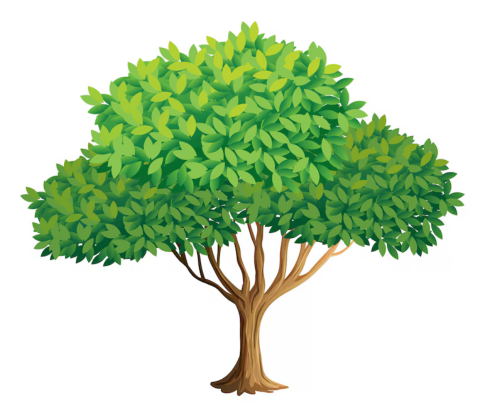

Translated Image:


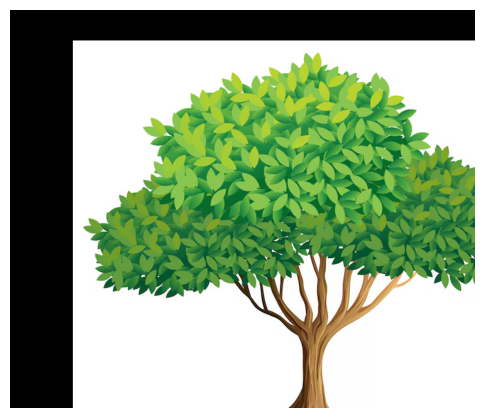

Rotated Image:


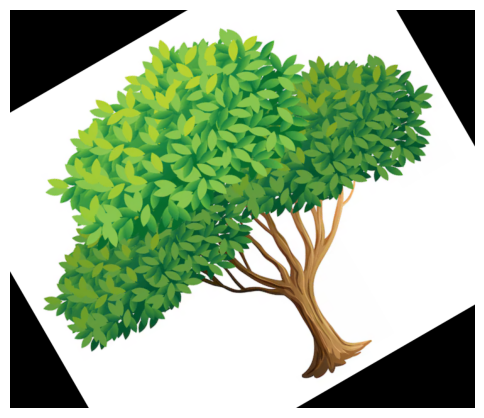

Scaled Image:


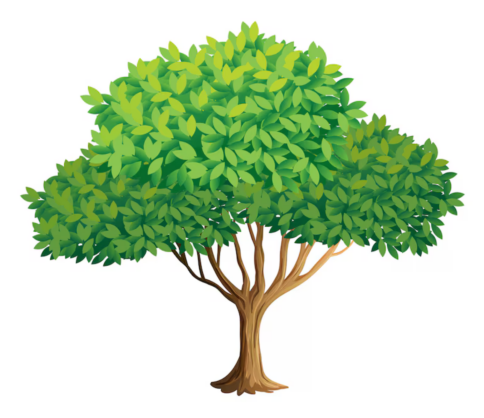

Sheared Image:


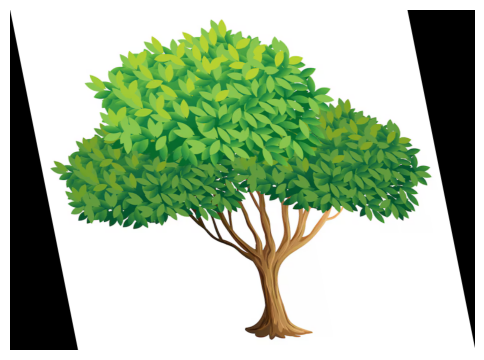

Flipped Horizontally:


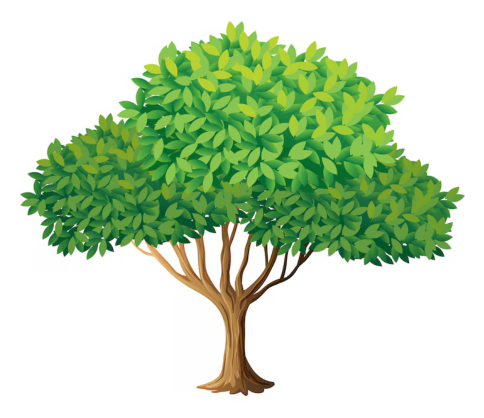

Flipped Vertically:


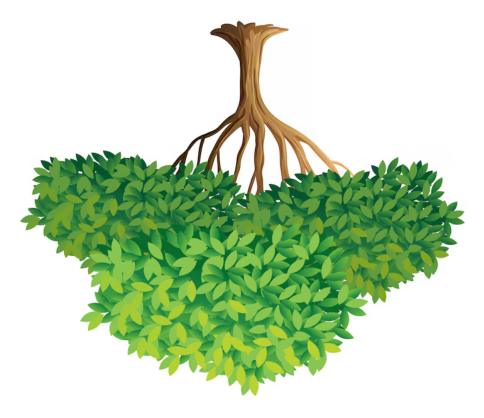

Flipped (Horizontal + Vertical):


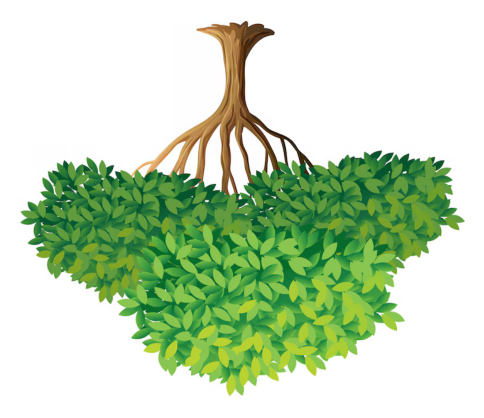

Cropped (Center ROI):


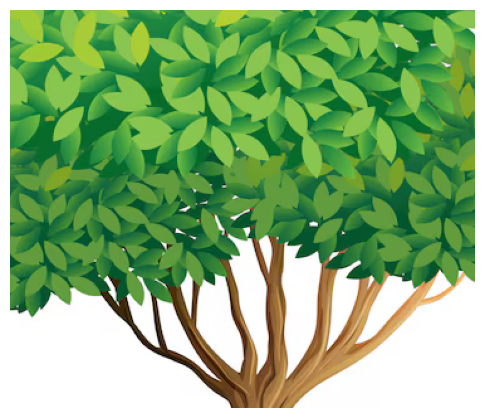

Cropped (Top-left ROI 250x250):


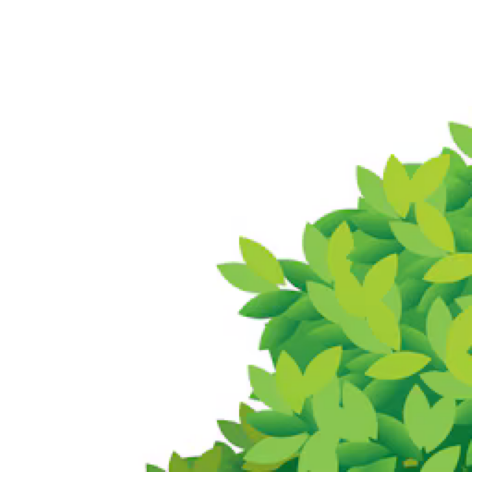

In [5]:
# Image Transformation
import cv2
import numpy as np

# If you're running this in Google Colab, these imports work.
# In local Jupyter/VS Code, they will fail; the fallback below will be used.
try:
    from google.colab.patches import cv2_imshow  # type: ignore
    from google.colab import files  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

    import matplotlib.pyplot as plt

    def cv2_imshow(img):
        # OpenCV uses BGR; matplotlib expects RGB
        if img is None:
            print("(empty image)")
            return
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.axis("off")
        plt.imshow(img, cmap="gray")
        plt.show()


def main():
    # Upload / choose the image
    if IN_COLAB:
        print("Please upload an image file:")
        uploaded = files.upload()
        image_path = list(uploaded.keys())[0]
    else:
        # Local fallback: set a path to an image on your machine
        image_path = "./tree_1308-36471.png"  # <-- change this

    # Load the image
    image = cv2.imread(image_path)

    if image is None:
        print("Error: Could not load image. Please check the file format/path.")
        return

    # Display original image
    print("Original Image:")
    cv2_imshow(image)

    # Get image dimensions
    height, width = image.shape[:2]

    # 1) Translation
    translation_matrix = np.float32([[1, 0, 100], [0, 1, 50]])  # right by 100, down by 50
    translated_image = cv2.warpAffine(image, translation_matrix, (width, height))
    print("Translated Image:")
    cv2_imshow(translated_image)

    # 2) Rotation (about image center)
    center = (width // 2, height // 2)
    angle_degrees = 30
    scale = 1.0
    rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, scale)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))
    print("Rotated Image:")
    cv2_imshow(rotated_image)

    # 3) Scaling (resize)
    fx, fy = 1.5, 1.5
    scaled_image = cv2.resize(image, None, fx=fx, fy=fy, interpolation=cv2.INTER_LINEAR)
    print("Scaled Image:")
    cv2_imshow(scaled_image)

    # 4) Shearing
    shear_x = 0.2
    shear_matrix = np.float32([[1, shear_x, 0], [0, 1, 0]])
    # output width increases because of shear
    sheared_image = cv2.warpAffine(image, shear_matrix, (int(width + shear_x * height), height))
    print("Sheared Image:")
    cv2_imshow(sheared_image)

    # 5) Flipping
    flipped_horizontal = cv2.flip(image, 1)  # 1 = horizontal flip
    print("Flipped Horizontally:")
    cv2_imshow(flipped_horizontal)

    flipped_vertical = cv2.flip(image, 0)  # 0 = vertical flip
    print("Flipped Vertically:")
    cv2_imshow(flipped_vertical)

    flipped_both = cv2.flip(image, -1)  # -1 = both axes
    print("Flipped (Horizontal + Vertical):")
    cv2_imshow(flipped_both)

    # 6) Cropping (ROI)
    # Example: crop a centered region (50% of width/height)
    crop_w = width // 2
    crop_h = height // 2
    x1 = (width - crop_w) // 2
    y1 = (height - crop_h) // 2
    x2 = x1 + crop_w
    y2 = y1 + crop_h

    cropped_center = image[y1:y2, x1:x2]
    print("Cropped (Center ROI):")
    cv2_imshow(cropped_center)

    # Example: crop by explicit coordinates (top-left ROI)
    x_start, y_start = 0, 0
    x_end = min(width, 250)
    y_end = min(height, 250)
    cropped_topleft = image[y_start:y_end, x_start:x_end]
    print("Cropped (Top-left ROI 250x250):")
    cv2_imshow(cropped_topleft)


if __name__ == "__main__":
    main()
